In [35]:
import random
import numpy as np
import torch
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scanpy as sc

from tqdm.auto import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

from cellina import CellinaModel

In [8]:
def set_seed(seed):
    random.seed(seed)                  # Python random
    np.random.seed(seed)               # NumPy
    torch.manual_seed(seed)            # PyTorch CPU
    torch.cuda.manual_seed(seed)       # PyTorch GPU (single-GPU)
    torch.cuda.manual_seed_all(seed)   # PyTorch GPU (multi-GPU)
    
    # Ensures deterministic behavior for some operations
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)

In [9]:
set_seed(0)

# Utils

In [5]:
def plot_results(df, alpha_type, target_col):
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x="alpha", y="score", width=0.5)
    sns.stripplot(data=df, x="alpha", y="score", color="black", size=5, jitter=True)
    plt.title(f"F1-score across seeds ({alpha_type}, target={target_col})")
    plt.xlabel(f"{alpha_type} value")
    plt.ylabel("F1-score")
    plt.show()

In [ ]:
def evaluate_models(
    seeds,
    alpha_type,
    alpha_values,
    target_col,
    root_dir="trained",
):
    """Evaluate trained models via linear classifier on latent space."""
    results = {alpha: [] for alpha in alpha_values}

    for alpha in tqdm(alpha_values, desc=f"Evaluating ({alpha_type})"):
        for seed in seeds:
            save_path = f"{root_dir}/{alpha_type}_{alpha}_seed_{seed}"

            model = CellinaModel.load(save_path, adata)

            adata.obsm['z'] = model.get_latent_representation(latent_key='z')

            X_train = adata[~adata.obs["is_holdout"]].X
            y_train = adata[~adata.obs["is_holdout"]].obs[target_col].values

            X_test = adata[adata.obs["is_holdout"]].X
            y_test = adata[adata.obs["is_holdout"]].obs[target_col].values

            clf = LogisticRegression(max_iter=5, solver="lbfgs")
            clf.fit(X_train, y_train)

            y_pred = clf.predict(X_test)
            score = f1_score(y_test, y_pred, average="macro")

            results[alpha].append(score)

    # convert to tidy DataFrame
    df = pd.DataFrame([
        {"alpha": alpha, "score": score}
        for alpha, scores in results.items()
        for score in scores
    ])

    return df

# Get dataset

In [11]:
adata = sc.read_h5ad("/data2/a330d/datasets/synthetic_spatial_adata_processed.h5ad")

# 1. Classifier

## Train

In [18]:
seeds = range(2)
alpha_ys = [0.01, 0.1]

In [14]:
CellinaModel.setup_anndata(adata,
                           batch_key="batch",
                           labels_key='cell_type', 
                           domains_key='region', 
                           spatial_obsm_key="spatial_x",
                           layer='counts')

INFO     Generating sequential column names                                                                        


In [23]:
for alpha in tqdm(alpha_ys, desc="Training (alpha_y)"):
    for seed in seeds:
        set_seed(seed)
        model = CellinaModel(
            adata, n_latent=20, classifier_lambda=alpha, discriminator_lambda=1e8
        )
        model.train(
            max_epochs=3,
            check_val_every_n_epoch=1,
            early_stopping=True,
            early_stopping_patience=25,
            early_stopping_monitor="validation_loss",  # NOTE: z/e kl + reconstruction
            train_size=0.9,
            validation_size=0.1,
            plan_kwargs={
                "lr": 0.0001,
                "weight_decay": 0.0001,
            },
            enable_checkpointing=True,
            batch_size=512,
            devices=[1],
        )

        model.save(f"trained/alpha_y_{alpha}_seed_{seed}", overwrite=True)


Training (alpha_y):   0%|          | 0/2 [00:00<?, ?it/s]

INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/a330d/miniforge3/envs/cellina/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/data/a330d/miniforge3/envs/cellina/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 3/3: 100%|██████████| 3/3 [00:05<00:00,  1.83s/it, v_num=1, train_loss=-1.05e+8]

`Trainer.fit` stopped: `max_epochs=3` reached.


...

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/a330d/miniforge3/envs/cellina/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/data/a330d/miniforge3/envs/cellina/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 3/3: 100%|██████████| 3/3 [00:05<00:00,  1.80s/it, v_num=1, train_loss=-1.06e+8]

`Trainer.fit` stopped: `max_epochs=3` reached.


Epoch 3/3: 100%|██████████| 3/3 [00:05<00:00,  1.82s/it, v_num=1, train_loss=-1.06e+8]

Training (alpha_y): 100%|██████████| 2/2 [00:22<00:00, 11.28s/it]

## Eval

In [33]:
# Set holdout set for evaluation
fraction = 0.1
n_cells = adata.n_obs
n_holdout = int(n_cells * fraction)

# Randomly choose cells
holdout_idx = np.random.choice(n_cells, n_holdout, replace=False)

# Set 'is_holdout' to False by default, then True for selected cells
adata.obs['is_holdout'] = False
adata.obs.iloc[holdout_idx, adata.obs.columns.get_loc('is_holdout')] = True

In [ ]:
df_alpha_y = evaluate_models(
    seeds,
    alpha_type="alpha_y",
    alpha_values=alpha_ys,
    target_col="cell_type",
    root_dir="trained",
)

Evaluating (alpha_y):   0%|          | 0/2 [00:00<?, ?it/s]Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File trained/alpha_y_0.01_seed_0/model.pt already downloaded                                              
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


/data/a330d/miniforge3/envs/cellina/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File trained/alpha_y_0.01_seed_1/model.pt already downloaded                                              
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


/data/a330d/miniforge3/envs/cellina/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
Evaluating (alpha_y):  50%|█████     | 1/2 [00:08<00:08,  8.06s/it]Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File trained/alpha_y_0.1_seed_0/model.pt already downloaded                                               
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


/data/a330d/miniforge3/envs/cellina/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File trained/alpha_y_0.1_seed_1/model.pt already downloaded                                               
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


/data/a330d/miniforge3/envs/cellina/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
Evaluating (alpha_y): 100%|██████████| 2/2 [00:15<00:00,  7.58s/it]


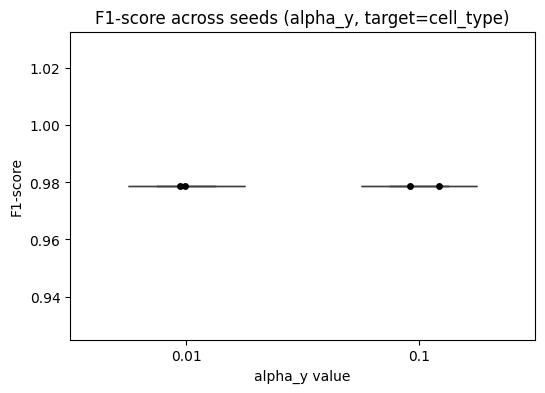

In [38]:
plot_results(df_alpha_y, alpha_type="alpha_y", target_col='cell_type')

# 2. Discriminator

## Train

In [ ]:
alpha_ds = [0.01, 0.1]

In [ ]:
for alpha in tqdm(alpha_ds, desc="Training (alpha_d)"):
    for seed in seeds:
        set_seed(seed)
        model = CellinaModel(
            adata, n_latent=20, classifier_lambda=1e10, discriminator_lambda=alpha
        )
        model.train(
            max_epochs=3,
            check_val_every_n_epoch=1,
            early_stopping=True,
            early_stopping_patience=25,
            early_stopping_monitor="validation_loss",  # NOTE: z/e kl + reconstruction
            train_size=0.9,
            validation_size=0.1,
            plan_kwargs={
                "lr": 0.0001,
                "weight_decay": 0.0001,
            },
            enable_checkpointing=True,
            batch_size=512,
            devices=[1],
        )

        model.save(f"trained/alpha_d_{alpha}_seed_{seed}", overwrite=True)


## Eval

In [ ]:
df_alpha_d = evaluate_models(
    seeds,
    alpha_type="alpha_d",
    alpha_values=alpha_ds,
    target_col="region",
    root_dir="trained",
)

In [ ]:
plot_results(df_alpha_d, alpha_type="alpha_d", target_col='region')